# Graph-Aware LLM Extraction for Structurally Robust Knowledge Graph Recommendation

This notebook runs the full pipeline from raw data to final results.
The experiment compares three KG construction methods — naive LLM extraction, taxonomy-constrained extraction, and the proposed graph-aware method — by feeding each into a GNN and measuring recommendation quality.

**Runtime:** A100 GPU recommended  
**Estimated time:** ~2 hours end to end (extraction is the bottleneck)

Steps:
1. Setup and dependencies
2. Data — download from Kaggle, sample 2k jobs
3. Pipeline 1 — Naive extraction
4. Pipeline 2 — Taxonomy-constrained extraction (ESCO)
5. Pipeline 3 — Graph-aware extraction (3 structural gates)
6. Graph structure analysis
7. GNN training — GraphSAGE and R-GCN
8. Robustness stress test
9. Ablation study

## 1. Setup

In [1]:
# install everything upfront so there are no mid-run interruptions
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q torch_geometric
!pip install -q transformers accelerate
!pip install -q sentence-transformers
!pip install -q kaggle
!pip install -q networkx pandas numpy matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.3 MB/s eta 0:00:00


In [2]:
import torch
import random
import numpy as np
import pandas as pd
import json
import time
import copy
import os
from pathlib import Path
from collections import defaultdict

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
# mount drive for persistent storage — outputs survive session resets
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/rsca-data'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted, outputs going to {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted, outputs going to /content/drive/MyDrive/rsca-data


In [4]:
# create local directory structure
dirs = [
    'data/raw/jobs',
    'data/raw/mappings',
    'data/processed/naive',
    'data/processed/taxonomy',
    'data/processed/graph_aware',
    'results'
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
print('Directory structure ready')

Directory structure ready


## 2. Data

Using the LinkedIn Job Postings dataset from Kaggle (~123k postings with ground truth skill labels).  
We need a Kaggle API key — add it to Colab Secrets as `KAGGLE_KEY` in the format `username:key`.

In [5]:
from google.colab import userdata

# set up kaggle credentials
os.environ['KAGGLE_USERNAME'] = 'uday1o1arora'
os.environ['KAGGLE_KEY'] = userdata.get('kaggle_api_key')

!kaggle datasets download -d arshkon/linkedin-job-postings -p data/raw/ --unzip -q
!ls data/raw/

Dataset URL: https://www.kaggle.com/datasets/arshkon/linkedin-job-postings
License(s): CC-BY-SA-4.0
companies  jobs  mappings  postings.csv


In [6]:
# move files into expected locations
import shutil

file_moves = [
    ('data/raw/jobs/job_skills.csv', 'data/raw/jobs/job_skills.csv'),
    ('data/raw/jobs/job_industries.csv', 'data/raw/jobs/job_industries.csv'),
    ('data/raw/mappings/skills.csv', 'data/raw/mappings/skills.csv'),
    ('data/raw/mappings/industries.csv', 'data/raw/mappings/industries.csv'),
]

# load the core files
postings = pd.read_csv('data/raw/postings.csv')
job_skills = pd.read_csv('data/raw/jobs/job_skills.csv')
job_industries = pd.read_csv('data/raw/jobs/job_industries.csv')
skills_map = pd.read_csv('data/raw/mappings/skills.csv')

print(f'Postings: {postings.shape}')
print(f'Job-skill pairs: {job_skills.shape}')
print(f'Unique jobs with labels: {job_skills["job_id"].nunique()}')
print(f'Skill categories: {job_skills["skill_abr"].nunique()}')

Postings: (123849, 31)
Job-skill pairs: (213768, 2)
Unique jobs with labels: 126807
Skill categories: 35


In [7]:
# sample 2000 jobs that have both a description and ground truth skill labels
# fixed seed = same 2000 jobs every run

labeled_jobs = set(job_skills['job_id'].unique())
usable = postings[
    postings['description'].notna() &
    postings['job_id'].isin(labeled_jobs)
].copy()

print(f'Usable postings (description + labels): {len(usable)}')

sample = usable.sample(n=2000, random_state=42)
sample = sample[['job_id', 'title', 'company_name', 'description']].reset_index(drop=True)

sample_skills = job_skills[job_skills['job_id'].isin(sample['job_id'])]
sample_industries = job_industries[job_industries['job_id'].isin(sample['job_id'])]

sample.to_csv('data/raw/sample_postings.csv', index=False)
sample_skills.to_csv('data/raw/sample_skills.csv', index=False)
sample_industries.to_csv('data/raw/sample_industries.csv', index=False)

print(f'Sample: {len(sample)} jobs, {len(sample_skills)} skill pairs')
print(f'Example titles: {sample["title"].head(5).tolist()}')

Usable postings (description + labels): 122090
Sample: 2000 jobs, 3366 skill pairs
Example titles: ['Leasing Manager', 'Pega Developer', 'WAREHOUSE ASSOC I - SSC', 'Sales Manager', 'Full Stack Software Engineer']


## 3. LLM Setup

Using Mistral-7B-Instruct loaded locally on the A100. No API costs, fully reproducible.  
Needs a HuggingFace token with access to the model — add as `HF_TOKEN` in Colab Secrets.

In [8]:
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM

login(token=userdata.get('HF_TOKEN'))

model_id = 'mistralai/Mistral-7B-Instruct-v0.3'
tokenizer = AutoTokenizer.from_pretrained(model_id)
llm = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map='cuda'
)

print(f'Model device: {next(llm.parameters()).device}')
print(f'GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB')

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model device: cuda:0
GPU memory used: 14.5 GB


In [9]:
# shared extraction prompt used by all three pipelines
# keeping this identical across pipelines is important for fair comparison
PROMPT_TEMPLATE = """You are a structured information extractor for job market data.
Extract relationships from the job description below.

Return ONLY a valid JSON array. Start with [ and end with ].
Each element must be an object with exactly these three string fields:
  "head": a single entity name (job title or skill name)
  "relation": MUST be one of these exact strings: requires, related_to, classified_as
  "tail": a single entity name (skill, tool, or competency)

Rules:
- Both head and tail must be plain strings, never arrays or lists.
- relation must be exactly requires, related_to, or classified_as.
- Extract one triple per skill — if a job requires Python and Java, make two separate triples.
- Only extract skills explicitly stated in the text. Do not infer or hallucinate.
- tail must be a concrete skill, tool, certification, or competency.
- Do not create triples where head and tail are paraphrases of each other.
- Return [] if no valid triples found.

Example output:
[
  {{"head": "software engineer", "relation": "requires", "tail": "python"}},
  {{"head": "software engineer", "relation": "requires", "tail": "java"}},
  {{"head": "python", "relation": "related_to", "tail": "django"}}
]

Job Title: {title}
Job Description: {description}

JSON array only, no explanation, no markdown:"""


def query_llm(prompt: str) -> str:
    inputs = tokenizer(prompt, return_tensors='pt').to(llm.device)
    with torch.no_grad():
        outputs = llm.generate(
            **inputs,
            max_new_tokens=500,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


def parse_triples(raw: str, job_id) -> list:
    try:
        cleaned = raw.strip()
        if '```' in cleaned:
            cleaned = cleaned.split('```')[1]
            if cleaned.startswith('json'):
                cleaned = cleaned[4:]
        if not cleaned.startswith('['):
            cleaned = '[' + cleaned
        if not cleaned.endswith(']'):
            last = cleaned.rfind('}')
            if last != -1:
                cleaned = cleaned[:last+1] + ']'
        triples = json.loads(cleaned)
        if not isinstance(triples, list):
            return []
        valid = []
        for t in triples:
            if not isinstance(t, dict):
                continue
            if not all(k in t for k in ['head', 'relation', 'tail']):
                continue
            if t['relation'] not in ['requires', 'related_to', 'classified_as']:
                continue
            tail = t['tail']
            if isinstance(tail, list):
                for item in tail:
                    valid.append({'job_id': job_id, 'head': str(t['head']).strip().lower(),
                                  'relation': t['relation'], 'tail': str(item).strip().lower()})
            else:
                valid.append({'job_id': job_id, 'head': str(t['head']).strip().lower(),
                              'relation': t['relation'], 'tail': str(tail).strip().lower()})
        return valid
    except json.JSONDecodeError:
        return []


# quick sanity check
test = query_llm("Say hello in one sentence.")
print(f'LLM working: {test[:80]}')

LLM working: 

Hello, I'm a friendly and helpful assistant, ready to make your life easier!




## 4. Pipeline 1 — Naive Extraction

Standard zero-shot prompting with no post-processing. This is the baseline that represents current practice.  
Every triple the LLM produces goes straight into the graph.

In [10]:
def run_extraction(input_csv, output_csv, limit=None):
    df = pd.read_csv(input_csv)
    if limit:
        df = df.head(limit)

    all_triples = []
    failed = 0

    for i, row in df.iterrows():
        job_id = row['job_id']
        title = str(row['title'])
        description = str(row['description'])[:2000]
        prompt = PROMPT_TEMPLATE.format(title=title, description=description)

        try:
            raw = query_llm(prompt)
            triples = parse_triples(raw, job_id)
            all_triples.extend(triples)
            print(f'[{i+1}/{len(df)}] {title[:40]:<40} -> {len(triples)} triples')
        except Exception as e:
            failed += 1
            print(f'[{i+1}/{len(df)}] FAILED: {job_id} -- {e}')

    results = pd.DataFrame(all_triples)
    Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
    results.to_csv(output_csv, index=False)
    shutil.copy(output_csv, f'{DRIVE_DIR}/{Path(output_csv).name}')

    print(f'\n{len(df)} jobs | {failed} failed | {len(all_triples)} total triples')
    return results


print('Starting naive extraction...')
naive_df = run_extraction(
    input_csv='data/raw/sample_postings.csv',
    output_csv='data/processed/naive/triples_full.csv'
)

Starting naive extraction...
[1/2000] Leasing Manager                          -> 5 triples
[2/2000] Pega Developer                           -> 13 triples
[3/2000] WAREHOUSE ASSOC I - SSC                  -> 1 triples
[4/2000] Sales Manager                            -> 15 triples
[5/2000] Full Stack Software Engineer             -> 18 triples
[6/2000] Accountant                               -> 10 triples
[7/2000] Level II Registered Nurse (RN) - Med Sur -> 8 triples
[8/2000] Inside Licensed Sales Agent              -> 4 triples
[9/2000] Endoscope Sterile Processing Technician  -> 4 triples
[10/2000] Delivery Specialist                      -> 18 triples
[11/2000] Accounting Clerk                         -> 6 triples
[12/2000] Maintenance Technician                   -> 5 triples
[13/2000] Consulting and Outsourcing Intern - Summ -> 4 triples
[14/2000] D365 BC Systems & Process Lead           -> 11 triples
[15/2000] CNA 3C Tele- *FT/DAYS*                   -> 6 triples
[16/2000] $$$ 

In [11]:
# quick look at what came out
print(f'Shape: {naive_df.shape}')
print(f'\nRelation distribution:')
print(naive_df['relation'].value_counts())
print(f'\nTop 15 most common skills:')
print(naive_df['tail'].value_counts().head(15))

Shape: (13968, 4)

Relation distribution:
relation
requires         10357
related_to        3415
classified_as      196
Name: count, dtype: int64

Top 15 most common skills:
tail
bachelor's degree                    46
customer service                     39
high school diploma or equivalent    36
excellent communication skills       34
communication skills                 31
java                                 29
python                               27
collaboration                        26
javascript                           25
attention to detail                  22
high school diploma or ged           22
bachelor’s degree                    22
sql                                  21
excel                                19
project management                   19
Name: count, dtype: int64


## 5. Pipeline 2 — Taxonomy-Constrained Extraction

Same extracted triples, but each skill (tail entity) is validated against the ESCO taxonomy using the ESCO API + semantic similarity.  
Skills that don't match any ESCO concept above the threshold are dropped.  
This is the grounding approach from the literature (Clavié & Soulié, 2023).

In [12]:
import requests
from sentence_transformers import SentenceTransformer, util as st_util

embedder = SentenceTransformer('all-MiniLM-L6-v2')
ESCO_THRESHOLD = 0.55


def match_esco(skill: str) -> dict:
    url = 'https://ec.europa.eu/esco/api/search'
    params = {'text': skill, 'language': 'en', 'type': 'skill', 'limit': 3}
    try:
        r = requests.get(url, params=params, timeout=10)
        results = r.json().get('_embedded', {}).get('results', [])
        if not results:
            return {'match': None, 'valid': False, 'score': 0.0}
        titles = [res.get('title', '') for res in results]
        skill_emb = embedder.encode(skill, convert_to_tensor=True)
        title_embs = embedder.encode(titles, convert_to_tensor=True)
        scores = st_util.cos_sim(skill_emb, title_embs)[0]
        best_idx = int(scores.argmax())
        best_score = float(scores[best_idx])
        return {
            'match': titles[best_idx],
            'score': round(best_score, 3),
            'valid': best_score >= ESCO_THRESHOLD
        }
    except Exception:
        return {'match': None, 'valid': False, 'score': 0.0}


# test on a few known skills before running the full set
for s in ['python', 'java', 'sql', 'excellent communication skills', 'underwater basket weaving']:
    r = match_esco(s)
    print(f"'{s}' -> '{r['match']}' (score: {r['score']}) -> {'PASS' if r['valid'] else 'FAIL'}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

'python' -> 'Python (computer programming)' (score: 0.883) -> PASS
'java' -> 'Java (computer programming)' (score: 0.858) -> PASS
'sql' -> 'SQL' (score: 1.0) -> PASS
'excellent communication skills' -> 'apply technical communication skills' (score: 0.631) -> PASS
'underwater basket weaving' -> 'perform basket weaving' (score: 0.718) -> PASS


In [13]:
def run_taxonomy_filter(naive_csv, output_csv):
    naive = pd.read_csv(naive_csv)
    print(f'Filtering {len(naive)} naive triples against ESCO...')

    cache = {}  # avoid re-calling ESCO for the same skill
    kept = []
    rejected = 0

    for _, row in naive.iterrows():
        tail = row['tail']
        if tail not in cache:
            cache[tail] = match_esco(tail)['valid']
            time.sleep(0.1)  # be polite to the ESCO API
        if cache[tail]:
            kept.append(row.to_dict())
        else:
            rejected += 1

    results = pd.DataFrame(kept)
    Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
    results.to_csv(output_csv, index=False)
    shutil.copy(output_csv, f'{DRIVE_DIR}/{Path(output_csv).name}')

    print(f'\nInput: {len(naive)} | Kept: {len(kept)} | Rejected: {rejected}')
    print(f'Rejection rate: {rejected/len(naive)*100:.1f}%')
    return results


taxonomy_df = run_taxonomy_filter(
    naive_csv='data/processed/naive/triples_full.csv',
    output_csv='data/processed/taxonomy/triples_full.csv'
)

Filtering 13968 naive triples against ESCO...

Input: 13968 | Kept: 6502 | Rejected: 7466
Rejection rate: 53.5%


## 6. Pipeline 3 — Graph-Aware Extraction (proposed method)

Three structural gates applied before any triple enters the graph:

- **Gate 1 — Cross-document corroboration:** A skill must appear in at least 2 job postings. Single-document mentions are likely hallucinations.
- **Gate 2 — Degree anomaly rejection:** Reject edges that would push a node's degree beyond mean + 2σ. Prevents hub node artifacts that corrupt GNN message passing.
- **Gate 3 — Relational type consistency:** Enforce valid head/tail entity type combinations per relation type.

In [14]:
naive_df = pd.read_csv('data/processed/naive/triples_full.csv')

# gate 1 — corroboration
MIN_DOCS = 2
tail_doc_counts = naive_df.groupby('tail')['job_id'].nunique()
corroborated = set(tail_doc_counts[tail_doc_counts >= MIN_DOCS].index)
after_gate1 = naive_df[naive_df['tail'].isin(corroborated)].copy()

print(f'Naive triples:  {len(naive_df):>6}')
print(f'After gate 1:   {len(after_gate1):>6}  (rejected {len(naive_df)-len(after_gate1)} single-doc triples)')

Naive triples:   13968
After gate 1:     3725  (rejected 10243 single-doc triples)


In [15]:
# gate 2 — degree anomaly
def remove_hub_triples(df, z_threshold=2.0):
    kept_rows = []
    degrees = defaultdict(int)

    for _, row in df.iterrows():
        head, tail = row['head'], row['tail']
        if len(degrees) > 0:
            vals = list(degrees.values())
            threshold = np.mean(vals) + z_threshold * np.std(vals)
        else:
            threshold = float('inf')
        # max(threshold, 5) so we don't reject everything in a sparse early graph
        if degrees[head] + 1 <= max(threshold, 5) and degrees[tail] + 1 <= max(threshold, 5):
            kept_rows.append(row)
            degrees[head] += 1
            degrees[tail] += 1

    return pd.DataFrame(kept_rows)


after_gate2 = remove_hub_triples(after_gate1)
print(f'After gate 2:   {len(after_gate2):>6}  (rejected {len(after_gate1)-len(after_gate2)} hub-forming edges)')

After gate 2:     2274  (rejected 1451 hub-forming edges)


In [16]:
# gate 3 — relational type consistency
VALID_RELATIONS = {
    'requires':      [('job_title', 'skill'), ('job_title', 'category')],
    'related_to':    [('skill', 'skill'), ('job_title', 'job_title')],
    'classified_as': [('job_title', 'category'), ('skill', 'category')]
}

def infer_types(df):
    types = {}
    for e in df[df['relation'] == 'classified_as']['tail'].unique():
        types[e] = 'category'
    for e in df[df['relation'] == 'requires']['head'].unique():
        if e not in types:
            types[e] = 'job_title'
    all_ents = set(df['head'].unique()) | set(df['tail'].unique())
    for e in all_ents:
        if e not in types:
            types[e] = 'skill'
    return types

def apply_type_gate(df):
    types = infer_types(df)
    kept = []
    rejected = 0
    for _, row in df.iterrows():
        h_type = types.get(row['head'], 'skill')
        t_type = types.get(row['tail'], 'skill')
        if (h_type, t_type) in VALID_RELATIONS.get(row['relation'], []):
            kept.append(row)
        else:
            rejected += 1
    print(f'After gate 3:   {len(kept):>6}  (rejected {rejected} type-inconsistent edges)')
    return pd.DataFrame(kept)


graph_aware_df = apply_type_gate(after_gate2)

# save
graph_aware_df.to_csv('data/processed/graph_aware/triples_full.csv', index=False)
shutil.copy('data/processed/graph_aware/triples_full.csv',
            f'{DRIVE_DIR}/triples_graph_aware_full.csv')

print(f'\nPipeline summary:')
print(f'  Naive:       {len(naive_df):>6} triples')
print(f'  Taxonomy:    {len(taxonomy_df):>6} triples  ({(1-len(taxonomy_df)/len(naive_df))*100:.1f}% rejected)')
print(f'  Graph-Aware: {len(graph_aware_df):>6} triples  ({(1-len(graph_aware_df)/len(naive_df))*100:.1f}% rejected)')

After gate 3:     2026  (rejected 248 type-inconsistent edges)

Pipeline summary:
  Naive:        13968 triples
  Taxonomy:      6502 triples  (53.5% rejected)
  Graph-Aware:   2026 triples  (85.5% rejected)


## 7. Graph Structure Analysis

Before training any GNN, compare the structural properties of the three graphs.  
The degree distribution is the key diagnostic — hub nodes (high degree) corrupt message passing.

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

def build_nx_graph(df, name):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_node(row['head'])
        G.add_node(row['tail'])
        G.add_edge(row['head'], row['tail'], relation=row['relation'])
    degrees = [d for _, d in G.degree()]
    print(f'{name}: nodes={G.number_of_nodes()} edges={G.number_of_edges()} '
          f'avg_deg={np.mean(degrees):.2f} max_deg={max(degrees)}')
    return G


G_naive = build_nx_graph(naive_df, 'Naive')
G_taxonomy = build_nx_graph(taxonomy_df, 'Taxonomy')
G_ga = build_nx_graph(graph_aware_df, 'Graph-Aware')

Naive: nodes=12712 edges=13529 avg_deg=2.13 max_deg=132
Taxonomy: nodes=6317 edges=6322 avg_deg=2.00 max_deg=51
Graph-Aware: nodes=1827 edges=1998 avg_deg=2.19 max_deg=5


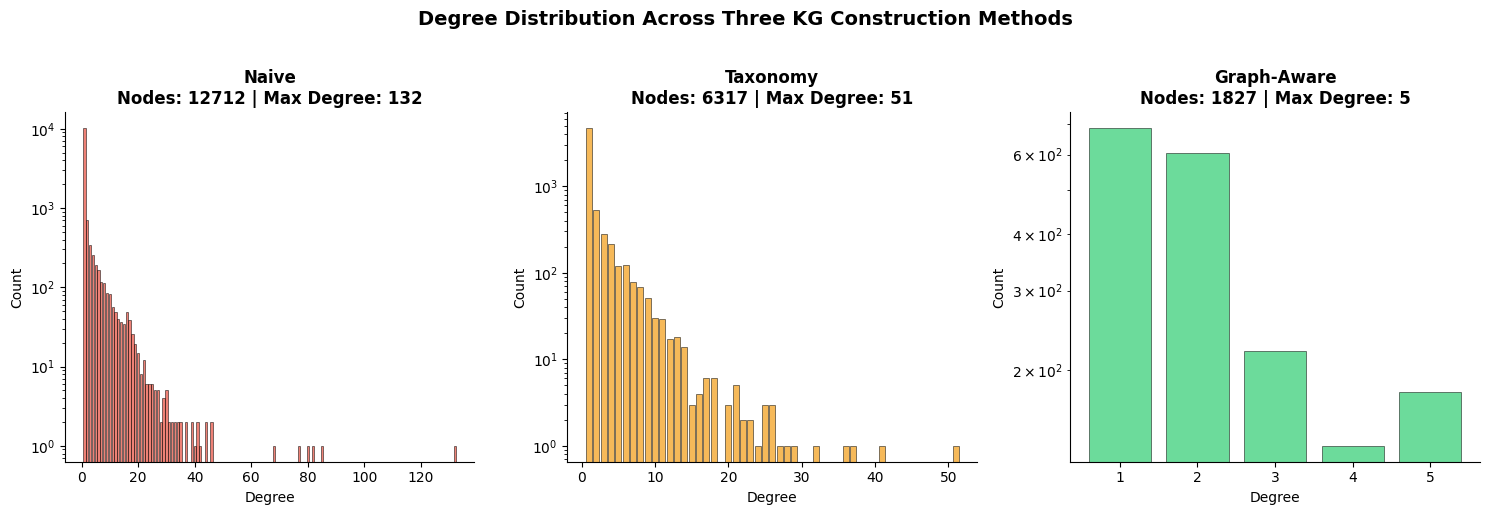

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
graphs = [G_naive, G_taxonomy, G_ga]
names = ['Naive', 'Taxonomy', 'Graph-Aware']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, G, name, color in zip(axes, graphs, names, colors):
    degrees = sorted([d for _, d in G.degree()], reverse=True)
    deg_counts = pd.Series(degrees).value_counts().sort_index()
    ax.bar(deg_counts.index, deg_counts.values, color=color, alpha=0.7,
           edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name}\nNodes: {G.number_of_nodes()} | Max Degree: {max(degrees)}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Degree Distribution Across Three KG Construction Methods',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/degree_distribution.png', dpi=150, bbox_inches='tight')
shutil.copy('results/degree_distribution.png', f'{DRIVE_DIR}/degree_distribution.png')
plt.show()

## 8. GNN Training — GraphSAGE

GraphSAGE is used for its inductive property — it can generalize to unseen nodes, which matters in job matching where new postings arrive continuously (Hamilton et al., 2017).  
Task: link prediction (does a job node connect to a skill node?).  
Evaluation: Recall@K and NDCG@K using sampled negatives (99 negatives per positive, standard protocol).

In [19]:
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F


def make_pyg_data(df):
    all_ents = pd.concat([df['head'], df['tail']]).unique()
    enc = LabelEncoder().fit(all_ents)
    src = torch.tensor(enc.transform(df['head'].values), dtype=torch.long)
    dst = torch.tensor(enc.transform(df['tail'].values), dtype=torch.long)
    edge_index = torch.stack([src, dst], dim=0)
    n = len(all_ents)
    x = torch.eye(n, 64) if n >= 64 else torch.eye(n)
    return Data(x=x, edge_index=edge_index, num_nodes=n)


data_naive = make_pyg_data(naive_df)
data_taxonomy = make_pyg_data(taxonomy_df)
data_ga = make_pyg_data(graph_aware_df)

for name, d in [('Naive', data_naive), ('Taxonomy', data_taxonomy), ('Graph-Aware', data_ga)]:
    print(f'{name}: nodes={d.num_nodes} edges={d.num_edges} feat_dim={d.x.shape[1]}')

Naive: nodes=12712 edges=13968 feat_dim=64
Taxonomy: nodes=6317 edges=6502 feat_dim=64
Graph-Aware: nodes=1827 edges=2026 feat_dim=64


In [20]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hidden_ch)
        self.conv2 = SAGEConv(hidden_ch, out_ch)

    def encode(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.conv2(x, edge_index)

    def decode(self, z, ei):
        return (z[ei[0]] * z[ei[1]]).sum(dim=-1)

    def forward(self, x, edge_index):
        return self.encode(x, edge_index)


def split_edges(data, test_r=0.2, val_r=0.1, seed=42):
    """Split edges so test nodes all appear in training (no cold-start leakage)."""
    torch.manual_seed(seed)
    ei = data.edge_index
    n = data.num_nodes
    src_cnt = torch.bincount(ei[0], minlength=n)
    dst_cnt = torch.bincount(ei[1], minlength=n)
    node_cnt = src_cnt + dst_cnt
    valid_mask = (node_cnt[ei[0]] >= 2) & (node_cnt[ei[1]] >= 2)
    valid_idx = valid_mask.nonzero(as_tuple=True)[0]
    invalid_idx = (~valid_mask).nonzero(as_tuple=True)[0]
    perm = torch.randperm(len(valid_idx))
    valid_idx = valid_idx[perm]
    ts = int(len(valid_idx) * test_r)
    vs = int(len(valid_idx) * val_r)
    test_ei = ei[:, valid_idx[:ts]]
    val_ei = ei[:, valid_idx[ts:ts+vs]]
    train_ei = ei[:, torch.cat([valid_idx[ts+vs:], invalid_idx])]
    return train_ei, val_ei, test_ei


def evaluate(z, pos_ei, k_vals=[5, 10], num_neg=99):
    device = z.device
    n = z.shape[0]
    num_test = pos_ei.shape[1]
    hits = {k: 0 for k in k_vals}
    ndcg = {k: 0.0 for k in k_vals}
    mrr = 0.0
    torch.manual_seed(42)
    for i in range(num_test):
        src = pos_ei[0, i].item()
        true_dst = pos_ei[1, i].item()
        gen = torch.Generator(device=device).manual_seed(i)
        negs = torch.randint(0, n, (num_neg,), device=device, generator=gen)
        cands = torch.cat([torch.tensor([true_dst], device=device), negs])
        scores = (z[src].unsqueeze(0) * z[cands]).sum(dim=-1)
        rank = (scores[0] < scores).sum().item() + 1
        mrr += 1.0 / rank
        for k in k_vals:
            if rank <= k:
                hits[k] += 1
                ndcg[k] += 1.0 / np.log2(rank + 1)
    return {
        **{f'recall@{k}': hits[k]/num_test for k in k_vals},
        **{f'ndcg@{k}': ndcg[k]/num_test for k in k_vals},
        'mrr': mrr/num_test
    }


def train_graphsage(data, name, epochs=150, lr=0.01, seed=42):
    set_seeds(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)
    train_ei, val_ei, test_ei = split_edges(data, seed=seed)

    model = GraphSAGE(data.x.shape[1], 128, 64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_val = float('inf')
    patience = 20
    p_count = 0

    for epoch in range(1, epochs+1):
        model.train()
        opt.zero_grad()
        z = model(data.x, train_ei)
        pos_s = model.decode(z, train_ei)
        neg_ei = negative_sampling(train_ei, data.num_nodes, train_ei.shape[1])
        neg_s = model.decode(z, neg_ei)
        loss = (F.binary_cross_entropy_with_logits(pos_s, torch.ones_like(pos_s)) +
                F.binary_cross_entropy_with_logits(neg_s, torch.zeros_like(neg_s)))
        loss.backward()
        opt.step()

        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                zv = model(data.x, train_ei)
                vp = model.decode(zv, val_ei)
                vn_ei = negative_sampling(val_ei, data.num_nodes, val_ei.shape[1])
                vn = model.decode(zv, vn_ei)
                val_loss = (F.binary_cross_entropy_with_logits(vp, torch.ones_like(vp)) +
                            F.binary_cross_entropy_with_logits(vn, torch.zeros_like(vn)))
            print(f'  Epoch {epoch:>3} | loss={loss.item():.4f} | val_loss={val_loss.item():.4f}')
            if val_loss < best_val:
                best_val = val_loss
                p_count = 0
            else:
                p_count += 1
                if p_count >= patience // 20:
                    print(f'  Early stopping at epoch {epoch}')
                    break

    model.eval()
    with torch.no_grad():
        z_test = model(data.x, train_ei)
        metrics = evaluate(z_test, test_ei)

    print(f'\n  {name}: R@10={metrics["recall@10"]:.4f} NDCG@10={metrics["ndcg@10"]:.4f} MRR={metrics["mrr"]:.4f}')
    return model, z_test, test_ei, metrics


print('GraphSAGE ready')

GraphSAGE ready


In [21]:
# multi-seed run for statistical validity
# 3 seeds is enough to show variance and get stable mean estimates

seeds = [42, 123, 456]
sage_runs = {'naive': [], 'taxonomy': [], 'graph_aware': []}
datasets = {'naive': data_naive, 'taxonomy': data_taxonomy, 'graph_aware': data_ga}

for seed in seeds:
    print(f'\n{"="*50}')
    print(f'Seed {seed}')
    print(f'{"="*50}')
    for name, data in datasets.items():
        print(f'\nTraining GraphSAGE {name}...')
        _, _, _, m = train_graphsage(data, name, seed=seed)
        sage_runs[name].append(m)

print(f'\n{"="*65}')
print('GRAPHSAGE MULTI-SEED RESULTS (mean +/- std)')
print(f'{"="*65}')
print(f'{"Pipeline":<15} {"R@10 mean+/-std":<22} {"NDCG@10 mean+/-std":<24} {"MRR mean+/-std"}')
print('-'*75)

sage_stats = {}
for name, runs in sage_runs.items():
    r10 = np.array([r['recall@10'] for r in runs])
    n10 = np.array([r['ndcg@10'] for r in runs])
    mrr = np.array([r['mrr'] for r in runs])
    sage_stats[name] = {
        'recall@10_mean': round(r10.mean(), 4), 'recall@10_std': round(r10.std(), 4),
        'ndcg@10_mean': round(n10.mean(), 4), 'ndcg@10_std': round(n10.std(), 4),
        'mrr_mean': round(mrr.mean(), 4), 'mrr_std': round(mrr.std(), 4),
    }
    print(f'{name:<15} {r10.mean():.4f}+/-{r10.std():.4f}          '
          f'{n10.mean():.4f}+/-{n10.std():.4f}           '
          f'{mrr.mean():.4f}+/-{mrr.std():.4f}')

with open('results/sage_multiseed.json', 'w') as f:
    json.dump(sage_stats, f, indent=2)
shutil.copy('results/sage_multiseed.json', f'{DRIVE_DIR}/sage_multiseed.json')


Seed 42

Training GraphSAGE naive...
  Epoch  20 | loss=1.3283 | val_loss=1.2439
  Epoch  40 | loss=1.3156 | val_loss=1.2624
  Early stopping at epoch 40

  naive: R@10=0.2478 NDCG@10=0.1702 MRR=0.1982

Training GraphSAGE taxonomy...
  Epoch  20 | loss=1.3733 | val_loss=1.3645
  Epoch  40 | loss=1.3603 | val_loss=1.3534
  Epoch  60 | loss=1.2763 | val_loss=1.3631
  Early stopping at epoch 60

  taxonomy: R@10=0.1232 NDCG@10=0.1232 MRR=0.1600

Training GraphSAGE graph_aware...
  Epoch  20 | loss=1.3671 | val_loss=1.3985
  Epoch  40 | loss=1.3608 | val_loss=1.4086
  Early stopping at epoch 40

  graph_aware: R@10=0.7914 NDCG@10=0.6533 MRR=0.6092

Seed 123

Training GraphSAGE naive...
  Epoch  20 | loss=1.3248 | val_loss=1.2757
  Epoch  40 | loss=1.3172 | val_loss=1.2551
  Epoch  60 | loss=1.3028 | val_loss=1.2730
  Early stopping at epoch 60

  naive: R@10=0.2466 NDCG@10=0.1613 MRR=0.1898

Training GraphSAGE taxonomy...
  Epoch  20 | loss=1.3695 | val_loss=1.3466
  Epoch  40 | loss=1.36

'/content/drive/MyDrive/rsca-data/sage_multiseed.json'

## 9. GNN Training — R-GCN

R-GCN uses typed relations (requires, related_to, classified_as) as separate convolution channels (Schlichtkrull et al., 2018).  
With only 3 relation types this is expected to underperform GraphSAGE, but confirms the trend is architecture-agnostic.

In [22]:
from torch_geometric.nn import RGCNConv

class RGCN(torch.nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, num_rel):
        super().__init__()
        self.conv1 = RGCNConv(in_ch, hidden_ch, num_rel)
        self.conv2 = RGCNConv(hidden_ch, out_ch, num_rel)

    def encode(self, x, ei, et):
        x = F.relu(self.conv1(x, ei, et))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.conv2(x, ei, et)

    def decode(self, z, ei):
        return (z[ei[0]] * z[ei[1]]).sum(dim=-1)

    def forward(self, x, ei, et):
        return self.encode(x, ei, et)


def train_rgcn(df, name, epochs=150, lr=0.01, seed=42):
    set_seeds(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    all_ents = pd.concat([df['head'], df['tail']]).unique()
    node_enc = LabelEncoder().fit(all_ents)
    rel_enc = LabelEncoder().fit(df['relation'].values)

    src = torch.tensor(node_enc.transform(df['head'].values), dtype=torch.long)
    dst = torch.tensor(node_enc.transform(df['tail'].values), dtype=torch.long)
    et = torch.tensor(rel_enc.transform(df['relation'].values), dtype=torch.long)
    ei = torch.stack([src, dst], dim=0)
    n = len(all_ents)
    x = (torch.eye(n, 64) if n >= 64 else torch.eye(n)).to(device)
    ei, et = ei.to(device), et.to(device)

    # fixed split
    torch.manual_seed(seed)
    perm = torch.randperm(ei.shape[1])
    ts, vs = int(ei.shape[1]*0.2), int(ei.shape[1]*0.1)
    test_ei = ei[:, perm[:ts]]
    val_ei = ei[:, perm[ts:ts+vs]]
    train_ei = ei[:, perm[ts+vs:]]
    train_et = et[perm[ts+vs:]]
    val_et = et[perm[ts:ts+vs]]

    model = RGCN(x.shape[1], 128, 64, len(rel_enc.classes_)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_val = float('inf')
    patience = 20
    p_count = 0

    for epoch in range(1, epochs+1):
        model.train()
        opt.zero_grad()
        z = model(x, train_ei, train_et)
        pos_s = model.decode(z, train_ei)
        neg_ei = negative_sampling(train_ei, n, train_ei.shape[1])
        neg_s = model.decode(z, neg_ei)
        loss = (F.binary_cross_entropy_with_logits(pos_s, torch.ones_like(pos_s)) +
                F.binary_cross_entropy_with_logits(neg_s, torch.zeros_like(neg_s)))
        loss.backward()
        opt.step()

        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                zv = model(x, train_ei, train_et)
                vp = model.decode(zv, val_ei)
                vn_ei = negative_sampling(val_ei, n, val_ei.shape[1])
                vn = model.decode(zv, vn_ei)
                val_loss = (F.binary_cross_entropy_with_logits(vp, torch.ones_like(vp)) +
                            F.binary_cross_entropy_with_logits(vn, torch.zeros_like(vn)))
            print(f'  Epoch {epoch:>3} | loss={loss.item():.4f} | val_loss={val_loss.item():.4f}')
            if val_loss < best_val:
                best_val = val_loss; p_count = 0
            else:
                p_count += 1
                if p_count >= patience // 20:
                    print(f'  Early stopping at epoch {epoch}')
                    break

    model.eval()
    with torch.no_grad():
        z_test = model(x, train_ei, train_et)
        metrics = evaluate(z_test, test_ei)

    print(f'  {name}: R@10={metrics["recall@10"]:.4f} NDCG@10={metrics["ndcg@10"]:.4f} MRR={metrics["mrr"]:.4f}')
    return model, z_test, test_ei, metrics, x, train_ei, train_et


print('R-GCN ready')

R-GCN ready


In [23]:
set_seeds(42)
rgcn_results = {}
rgcn_models = {}

for name, df in [('naive', naive_df), ('taxonomy', taxonomy_df), ('graph_aware', graph_aware_df)]:
    print(f'\nTraining R-GCN {name}...')
    model, z, test_ei, m, x, t_ei, t_et = train_rgcn(df, name)
    rgcn_results[name] = m
    rgcn_models[name] = (model, z, test_ei, x, t_ei, t_et)

print(f'\n{"="*65}')
print('FULL COMPARISON — GraphSAGE vs R-GCN')
print(f'{"="*65}')
print(f'{"Pipeline":<15} {"SAGE R@10":<12} {"RGCN R@10":<12} {"SAGE NDCG@10":<14} {"RGCN NDCG@10"}')
print('-'*65)
for name in ['naive', 'taxonomy', 'graph_aware']:
    print(f'{name:<15} {sage_stats[name]["recall@10_mean"]:<12.4f} '
          f'{rgcn_results[name]["recall@10"]:<12.4f} '
          f'{sage_stats[name]["ndcg@10_mean"]:<14.4f} '
          f'{rgcn_results[name]["ndcg@10"]:.4f}')


Training R-GCN naive...
  Epoch  20 | loss=1.3775 | val_loss=1.3829
  Epoch  40 | loss=1.0628 | val_loss=1.3904
  Early stopping at epoch 40
  naive: R@10=0.0523 NDCG@10=0.0379 MRR=0.0783

Training R-GCN taxonomy...
  Epoch  20 | loss=1.3692 | val_loss=1.3858
  Epoch  40 | loss=1.0766 | val_loss=1.3886
  Early stopping at epoch 40
  taxonomy: R@10=0.1046 NDCG@10=0.0607 MRR=0.0915

Training R-GCN graph_aware...
  Epoch  20 | loss=1.3651 | val_loss=1.4066
  Epoch  40 | loss=1.3418 | val_loss=1.4186
  Early stopping at epoch 40
  graph_aware: R@10=0.4741 NDCG@10=0.1891 MRR=0.1281

FULL COMPARISON — GraphSAGE vs R-GCN
Pipeline        SAGE R@10    RGCN R@10    SAGE NDCG@10   RGCN NDCG@10
-----------------------------------------------------------------
naive           0.2357       0.0523       0.1634         0.0379
taxonomy        0.1111       0.1046       0.1098         0.0607
graph_aware     0.7446       0.4741       0.5938         0.1891


## 10. Robustness Stress Test

Adversarial perturbation at 5%, 10%, and 20% noise.  
Two noise types: edge deletion (simulates missing data / sparse job descriptions) and edge insertion (simulates hallucinated skills being added downstream).  
Metric: drop in Recall@10 from clean baseline.

In [24]:
def perturb(data, level, noise_type):
    d = copy.deepcopy(data)
    n_edges = d.edge_index.shape[1]
    n_perturb = int(n_edges * level)
    device = d.edge_index.device
    if noise_type == 'deletion':
        keep = torch.randperm(n_edges)[n_perturb:]
        d.edge_index = d.edge_index[:, keep]
    else:
        fake = torch.randint(0, d.num_nodes, (2, n_perturb), device=device)
        d.edge_index = torch.cat([d.edge_index, fake], dim=1)
    return d


def robustness_eval(model, data, test_ei, noise_levels, noise_type, name):
    device = next(model.parameters()).device
    rows = []
    model.eval()
    with torch.no_grad():
        z0 = model(data.x, data.edge_index)
        m0 = evaluate(z0, test_ei)
    rows.append({'pipeline': name, 'noise_type': noise_type,
                 'noise_level': 0.0, **m0})
    print(f'{name} {noise_type} | clean R@10={m0["recall@10"]:.4f}')
    for level in noise_levels:
        p = perturb(data, level, noise_type).to(device)
        with torch.no_grad():
            zp = model(p.x, p.edge_index)
            mp = evaluate(zp, test_ei)
        deg = m0['recall@10'] - mp['recall@10']
        rows.append({'pipeline': name, 'noise_type': noise_type,
                     'noise_level': level, **mp, 'degradation': deg})
        print(f'  noise={level*100:.0f}% R@10={mp["recall@10"]:.4f} (deg={deg:+.4f})')
    return rows


# train one model per pipeline for robustness eval (use seed 42)
robust_models = {}
for name, data in [('Naive', data_naive), ('Taxonomy', data_taxonomy), ('Graph-Aware', data_ga)]:
    print(f'Training {name} for robustness eval...')
    model, z, test_ei, m = train_graphsage(data, name, seed=42)
    robust_models[name] = (model, data.to('cuda'), test_ei.to('cuda'))

Training Naive for robustness eval...
  Epoch  20 | loss=1.3283 | val_loss=1.2439
  Epoch  40 | loss=1.3156 | val_loss=1.2624
  Early stopping at epoch 40

  Naive: R@10=0.2103 NDCG@10=0.1588 MRR=0.1837
Training Taxonomy for robustness eval...
  Epoch  20 | loss=1.3733 | val_loss=1.3645
  Epoch  40 | loss=1.3603 | val_loss=1.3534
  Epoch  60 | loss=1.2763 | val_loss=1.3631
  Early stopping at epoch 60

  Taxonomy: R@10=0.1232 NDCG@10=0.1232 MRR=0.1575
Training Graph-Aware for robustness eval...
  Epoch  20 | loss=1.3671 | val_loss=1.3985
  Epoch  40 | loss=1.3608 | val_loss=1.4086
  Early stopping at epoch 40

  Graph-Aware: R@10=0.7914 NDCG@10=0.6533 MRR=0.6092


In [25]:
noise_levels = [0.05, 0.10, 0.20]
all_robust_rows = []

for noise_type in ['deletion', 'insertion']:
    print(f'\n--- {noise_type.upper()} ---')
    for name, (model, data, test_ei) in robust_models.items():
        rows = robustness_eval(model, data, test_ei, noise_levels, noise_type, name)
        all_robust_rows.extend(rows)

robust_df = pd.DataFrame(all_robust_rows)
robust_df.to_csv('results/robustness_results.csv', index=False)
shutil.copy('results/robustness_results.csv', f'{DRIVE_DIR}/robustness_results.csv')
print('\nRobustness results saved.')


--- DELETION ---
Naive deletion | clean R@10=0.0964
  noise=5% R@10=0.0150 (deg=+0.0814)
  noise=10% R@10=0.0075 (deg=+0.0889)
  noise=20% R@10=0.0238 (deg=+0.0726)
Taxonomy deletion | clean R@10=0.0000
  noise=5% R@10=0.0000 (deg=+0.0000)
  noise=10% R@10=0.0048 (deg=-0.0048)
  noise=20% R@10=0.0145 (deg=-0.0145)
Graph-Aware deletion | clean R@10=0.9065
  noise=5% R@10=0.9137 (deg=-0.0072)
  noise=10% R@10=0.9101 (deg=-0.0036)
  noise=20% R@10=0.8849 (deg=+0.0216)

--- INSERTION ---
Naive insertion | clean R@10=0.0964
  noise=5% R@10=0.1302 (deg=-0.0338)
  noise=10% R@10=0.1727 (deg=-0.0763)
  noise=20% R@10=0.2403 (deg=-0.1439)
Taxonomy insertion | clean R@10=0.0000
  noise=5% R@10=0.0000 (deg=+0.0000)
  noise=10% R@10=0.0000 (deg=+0.0000)
  noise=20% R@10=0.0048 (deg=-0.0048)
Graph-Aware insertion | clean R@10=0.9065
  noise=5% R@10=0.8993 (deg=+0.0072)
  noise=10% R@10=0.8957 (deg=+0.0108)
  noise=20% R@10=0.8885 (deg=+0.0180)

Robustness results saved.


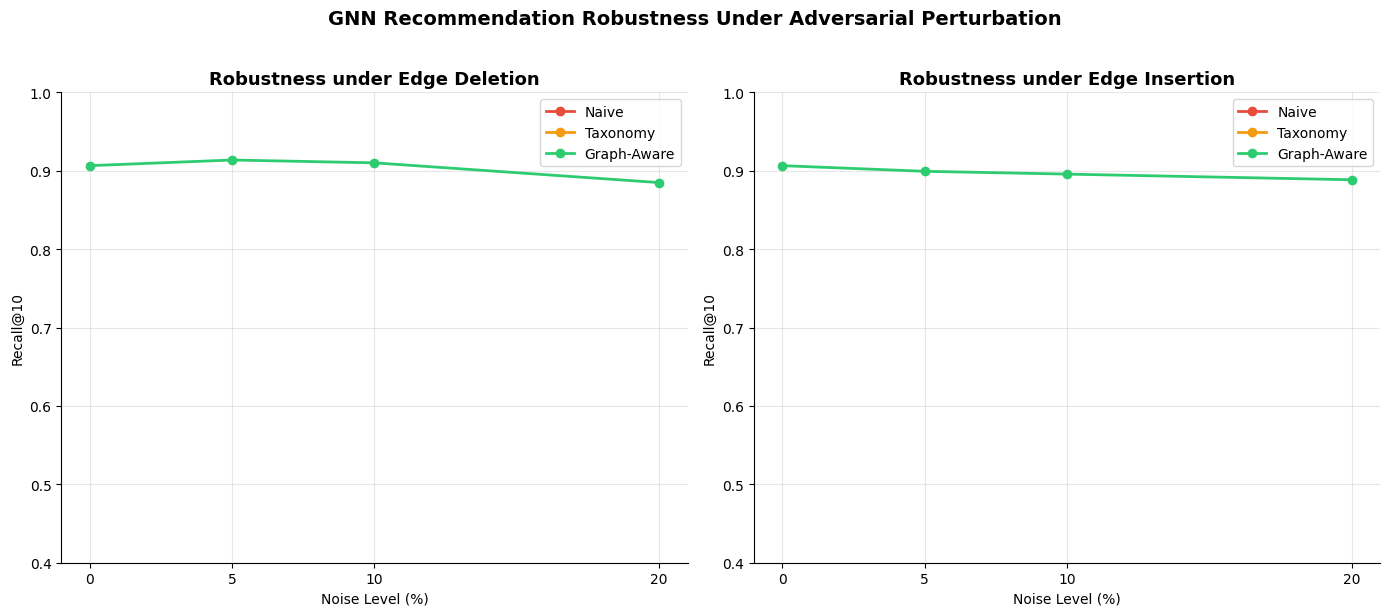

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {'Naive': '#e74c3c', 'Taxonomy': '#f39c12', 'Graph-Aware': '#2ecc71'}

for ax, noise_type in zip(axes, ['deletion', 'insertion']):
    sub = robust_df[robust_df['noise_type'] == noise_type]
    for pipeline in ['Naive', 'Taxonomy', 'Graph-Aware']:
        d = sub[sub['pipeline'] == pipeline].sort_values('noise_level')
        ax.plot(d['noise_level']*100, d['recall@10'], marker='o',
                linewidth=2, label=pipeline, color=colors[pipeline])
    ax.set_title(f'Robustness under Edge {noise_type.capitalize()}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Noise Level (%)')
    ax.set_ylabel('Recall@10')
    ax.set_xticks([0, 5, 10, 20])
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('GNN Recommendation Robustness Under Adversarial Perturbation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/robustness_curves.png', dpi=150, bbox_inches='tight')
shutil.copy('results/robustness_curves.png', f'{DRIVE_DIR}/robustness_curves.png')
plt.show()

## 11. Ablation Study

Test each gate's individual contribution by running three intermediate configurations:
- Gate 1 only (corroboration)
- Gate 1+2 (corroboration + degree anomaly)
- Gate 1+2+3 (full graph-aware)

This isolates what each structural filter actually contributes to downstream recommendation quality.

In [27]:
# rebuild the intermediate graphs
gate1_df = after_gate1.copy()
gate12_df = after_gate2.copy()
gate123_df = graph_aware_df.copy()

data_g1 = make_pyg_data(gate1_df)
data_g12 = make_pyg_data(gate12_df)
data_g123 = make_pyg_data(gate123_df)

print(f'Gate 1 only:  {len(gate1_df)} triples')
print(f'Gate 1+2:     {len(gate12_df)} triples')
print(f'Gate 1+2+3:   {len(gate123_df)} triples')

Gate 1 only:  3725 triples
Gate 1+2:     2274 triples
Gate 1+2+3:   2026 triples


In [28]:
set_seeds(42)
ablation = {}
configs = [
    ('gate1_only', data_g1, gate1_df),
    ('gate1+2', data_g12, gate12_df),
    ('gate1+2+3', data_g123, gate123_df),
]

for name, data, df in configs:
    print(f'\nTraining {name}...')
    _, _, _, m = train_graphsage(data, name, seed=42)
    ablation[name] = {'triples': len(df), **m}

print(f'\n{"="*60}')
print('ABLATION STUDY')
print(f'{"="*60}')
print(f'{"Config":<15} {"Triples":<10} {"R@10":<10} {"NDCG@10":<12} {"MRR"}')
print('-'*55)
# include naive as baseline row
print(f'{"naive (baseline)":<15} {len(naive_df):<10} '
      f'{sage_stats["naive"]["recall@10_mean"]:<10.4f} '
      f'{sage_stats["naive"]["ndcg@10_mean"]:<12.4f} '
      f'{sage_stats["naive"]["mrr_mean"]:.4f}')
for name, m in ablation.items():
    print(f'{name:<15} {m["triples"]:<10} {m["recall@10"]:<10.4f} '
          f'{m["ndcg@10"]:<12.4f} {m["mrr"]:.4f}')

with open('results/ablation.json', 'w') as f:
    json.dump({k: {m: round(v,4) for m,v in vals.items()}
               for k,vals in ablation.items()}, f, indent=2)
shutil.copy('results/ablation.json', f'{DRIVE_DIR}/ablation.json')


Training gate1_only...
  Epoch  20 | loss=1.3797 | val_loss=1.3869
  Epoch  40 | loss=1.3671 | val_loss=1.3870
  Early stopping at epoch 40

  gate1_only: R@10=0.7158 NDCG@10=0.4139 MRR=0.3216

Training gate1+2...
  Epoch  20 | loss=1.3702 | val_loss=1.3823
  Epoch  40 | loss=1.3686 | val_loss=1.3889
  Early stopping at epoch 40

  gate1+2: R@10=0.7706 NDCG@10=0.6314 MRR=0.5874

Training gate1+2+3...
  Epoch  20 | loss=1.3671 | val_loss=1.3985
  Epoch  40 | loss=1.3608 | val_loss=1.4086
  Early stopping at epoch 40

  gate1+2+3: R@10=0.7914 NDCG@10=0.6533 MRR=0.6092

ABLATION STUDY
Config          Triples    R@10       NDCG@10      MRR
-------------------------------------------------------
naive (baseline) 13968      0.2357     0.1634       0.1944
gate1_only      3725       0.7158     0.4139       0.3216
gate1+2         2274       0.7706     0.6314       0.5874
gate1+2+3       2026       0.7914     0.6533       0.6092


'/content/drive/MyDrive/rsca-data/ablation.json'

## 12. Final Results Summary

In [29]:
print('PIPELINE TRIPLE COUNTS')
print(f'  Naive:       {len(naive_df):>6}')
print(f'  Taxonomy:    {len(taxonomy_df):>6}  ({(1-len(taxonomy_df)/len(naive_df))*100:.1f}% rejected)')
print(f'  Graph-Aware: {len(graph_aware_df):>6}  ({(1-len(graph_aware_df)/len(naive_df))*100:.1f}% rejected)')

print(f'\nGRAPH STRUCTURE (max degree)')
print(f'  Naive:       {max(d for _,d in G_naive.degree())}')
print(f'  Taxonomy:    {max(d for _,d in G_taxonomy.degree())}')
print(f'  Graph-Aware: {max(d for _,d in G_ga.degree())}')

print(f'\nGRAPHSAGE RESULTS (mean +/- std, 3 seeds)')
print(f'{"Pipeline":<15} {"R@10":<20} {"NDCG@10":<20} {"MRR"}')
for name in ['naive', 'taxonomy', 'graph_aware']:
    s = sage_stats[name]
    print(f'{name:<15} {s["recall@10_mean"]:.4f}+/-{s["recall@10_std"]:.4f}      '
          f'{s["ndcg@10_mean"]:.4f}+/-{s["ndcg@10_std"]:.4f}      '
          f'{s["mrr_mean"]:.4f}+/-{s["mrr_std"]:.4f}')

print(f'\nR-GCN RESULTS (seed 42)')
print(f'{"Pipeline":<15} {"R@10":<10} {"NDCG@10":<12} {"MRR"}')
for name in ['naive', 'taxonomy', 'graph_aware']:
    m = rgcn_results[name]
    print(f'{name:<15} {m["recall@10"]:<10.4f} {m["ndcg@10"]:<12.4f} {m["mrr"]:.4f}')

# save everything together
summary = {
    'triple_counts': {'naive': len(naive_df), 'taxonomy': len(taxonomy_df), 'graph_aware': len(graph_aware_df)},
    'max_degree': {
        'naive': max(d for _,d in G_naive.degree()),
        'taxonomy': max(d for _,d in G_taxonomy.degree()),
        'graph_aware': max(d for _,d in G_ga.degree())
    },
    'graphsage_multiseed': sage_stats,
    'rgcn_seed42': {k: {m: round(v,4) for m,v in vals.items()} for k,vals in rgcn_results.items()},
    'ablation': ablation
}
with open('results/all_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
shutil.copy('results/all_results.json', f'{DRIVE_DIR}/all_results.json')
print('\nAll results saved to Drive.')

PIPELINE TRIPLE COUNTS
  Naive:        13968
  Taxonomy:      6502  (53.5% rejected)
  Graph-Aware:   2026  (85.5% rejected)

GRAPH STRUCTURE (max degree)
  Naive:       132
  Taxonomy:    51
  Graph-Aware: 5

GRAPHSAGE RESULTS (mean +/- std, 3 seeds)
Pipeline        R@10                 NDCG@10              MRR
naive           0.2357+/-0.0162      0.1634+/-0.0050      0.1944+/-0.0035
taxonomy        0.1111+/-0.0138      0.1098+/-0.0151      0.1452+/-0.0179
graph_aware     0.7446+/-0.0765      0.5938+/-0.0673      0.5469+/-0.0629

R-GCN RESULTS (seed 42)
Pipeline        R@10       NDCG@10      MRR
naive           0.0523     0.0379       0.0783
taxonomy        0.1046     0.0607       0.0915
graph_aware     0.4741     0.1891       0.1281

All results saved to Drive.
